# DGCL Rust (`dig_io`) 검증·벤치 노트북

DGCL 분자 파이프라인에 추가한 Rust 경로(`dig_io`)를 **선택적으로** 실행/검증/벤치합니다.

규칙: 기존 Python 구현은 그대로 두고, `impl='python'|'rust'` (view fn / `key_split`) 또는 `loader='pt'|'shard'` (MoleculeNet) 토글로만 갈아끼웁니다. 기본값은 전부 기존 동작.

## 셀 순서
1. 환경 확인 (Python / torch / `dig_io`)
2. (선택) `dig_io` Rust 확장 빌드
3. view fn 정확성 검증 (`verify_views_backend.py`)
4. view fn 마이크로벤치 — Python vs Rust 시간 비교
5. `scaffold_split` / `key_split` bit-equality 검증
6. (선택) `MoleculeNet` → `data.shard` 변환
7. `MoleculeNet` vs `MoleculeNetShard` 로드/이터레이션 벤치
8. `dig_io` 미설치 환경 폴백 검증
9. 결과 요약 + 시각화 (`bench/figs/`)

## 0. 공통 설정

경로/데이터셋 이름을 결정하고, 셀에서 공통으로 쓰는 `run()` 헬퍼를 정의합니다.

In [2]:
import os
import shlex
import subprocess
import sys
import time
from pathlib import Path

NB_DIR = Path.cwd()
if NB_DIR.name != "bench":
    NB_DIR = Path("examples/sslgraph/bench").resolve()
EXAMPLES_ROOT = NB_DIR.parent
REPO_ROOT = EXAMPLES_ROOT.parent.parent
DIG_IO_ROOT = REPO_ROOT / "dig_io"
FIGS_DIR = NB_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)
FIG_TS = time.strftime("%m%d_%H%M")
PY = Path(sys.executable)

MOLNET_NAME = "BBBP"
DATA_ROOT = REPO_ROOT / "datasets" / "molnet"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"REPO_ROOT     : {REPO_ROOT}")
print(f"EXAMPLES_ROOT : {EXAMPLES_ROOT}")
print(f"DIG_IO_ROOT   : {DIG_IO_ROOT}")
print(f"FIGS_DIR      : {FIGS_DIR}")
print(f"Python        : {PY}")
print(f"MolNet target : {MOLNET_NAME}  (root={DATA_ROOT})")


def run(cmd, cwd=REPO_ROOT, check=True, env=None):
    """Run subprocess and stream its output."""
    if isinstance(cmd, str):
        shown = cmd
        args = cmd if os.name == "nt" else shlex.split(cmd)
        shell = True
    else:
        shown = " ".join(str(a) for a in cmd)
        args = [str(a) for a in cmd]
        shell = False
    print(f"$ {shown}\n  (cwd={cwd})")
    proc = subprocess.Popen(
        args, cwd=str(cwd), shell=shell, env=env,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
        bufsize=1, encoding="utf-8", errors="replace",
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    if check and proc.returncode != 0:
        raise RuntimeError(f"Command failed (rc={proc.returncode}): {shown}")
    return proc.returncode

REPO_ROOT     : c:\DGCL\3DGCL
EXAMPLES_ROOT : c:\DGCL\3DGCL\examples\sslgraph
DIG_IO_ROOT   : c:\DGCL\3DGCL\dig_io
FIGS_DIR      : c:\DGCL\3DGCL\examples\sslgraph\bench\figs
Python        : c:\DGCL\3DGCL\.venv\Scripts\python.exe
MolNet target : BBBP  (root=c:\DGCL\3DGCL\datasets\molnet)


## 1. 환경 확인 — Python / torch / `dig_io`

`dig_io.is_available()` 가 True 면 Rust 경로가 활성, False 면 모든 셀이 Python 경로로 폴백합니다.

In [3]:
import platform

import torch

print(f"OS           : {platform.platform()}")
print(f"Python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"CUDA avail   : {torch.cuda.is_available()}")
xpu_ok = hasattr(torch, "xpu") and torch.xpu.is_available()
print(f"XPU  avail   : {xpu_ok}")
if xpu_ok:
    print(f"XPU device   : {torch.xpu.get_device_name(0)}")
print(f"CPU cores    : {os.cpu_count()}")

DIG_IO_AVAILABLE = False
try:
    import dig_io  # type: ignore
    DIG_IO_AVAILABLE = bool(dig_io.is_available())
    info = dig_io.format_info() if DIG_IO_AVAILABLE else None
    print(f"dig_io       : {'OK' if DIG_IO_AVAILABLE else 'imported but native missing'}", info or "")
except Exception as e:  # pragma: no cover
    print(f"dig_io       : NOT IMPORTABLE  ({e})")
    print("               -> run the 'Build dig_io' cell below.")

OS           : Windows-10-10.0.26200-SP0
Python       : 3.10.20
torch        : 2.9.1+xpu
CUDA avail   : False
XPU  avail   : True
XPU device   : Intel(R) Arc(TM) 140V GPU (16GB)
CPU cores    : 8
dig_io       : OK {'magic': b'DIGSHRD\x00', 'version': 1, 'header_size': 64, 'record_header_size': 40, 'flag_has_mmff': 1}


## 2. (선택) `dig_io` Rust 확장 빌드

한 번만 실행하면 됩니다. 빌드는 다음 순서로 시도합니다.

1. `pip install -e dig_io` (maturin develop 사용)
2. 실패 시 `cargo build --release --manifest-path dig_io/Cargo.toml` 후 빌드된 `.pyd`/`.so` 를 패키지 안에 사이드카로 복사

Windows 에서 커널이 `.pyd` 를 잠그고 있어 1번이 실패하면, 커널 재시작 후 다시 실행하거나 2번이 자동으로 받아치도록 둡니다.

In [4]:
BUILD_DIG_IO = not DIG_IO_AVAILABLE

if BUILD_DIG_IO:
    env = os.environ.copy()
    env.setdefault("PYO3_PYTHON", str(PY))

    print("[step 1/2] pip install -e dig_io ...")
    rc = subprocess.call(
        [str(PY), "-m", "pip", "install", "-e", str(DIG_IO_ROOT)],
        cwd=str(REPO_ROOT), env=env,
    )
    if rc != 0:
        print(f"  pip install failed (rc={rc}); falling back to cargo build.")
        rc2 = subprocess.call(
            ["cargo", "build", "--release", "--manifest-path", str(DIG_IO_ROOT / "Cargo.toml")],
            cwd=str(REPO_ROOT), env=env,
        )
        if rc2 != 0:
            raise RuntimeError(f"cargo build failed (rc={rc2})")
        target_dir = DIG_IO_ROOT / "target" / "release"
        cands = list(target_dir.glob("dig_io*.dll")) + list(target_dir.glob("libdig_io*.so")) + list(target_dir.glob("libdig_io*.dylib"))
        if not cands:
            raise RuntimeError(f"no built artifact under {target_dir}")
        src = cands[0]
        pkg = DIG_IO_ROOT / "python" / "dig_io"
        dst_name = "_native.pyd" if src.suffix == ".dll" else ("_native.dylib" if src.suffix == ".dylib" else "_native.so")
        dst = pkg / dst_name
        import shutil as _sh
        _sh.copyfile(src, dst)
        print(f"  copied {src.name} -> {dst}")

    import importlib
    if "dig_io" in sys.modules:
        importlib.reload(sys.modules["dig_io"])
    import dig_io  # type: ignore
    DIG_IO_AVAILABLE = bool(dig_io.is_available())
    print("dig_io       :", "OK" if DIG_IO_AVAILABLE else "FAILED")
else:
    print("Skipping build (dig_io already available). Set BUILD_DIG_IO = True to force.")

Skipping build (dig_io already available). Set BUILD_DIG_IO = True to force.


## 3. view fn 정확성 검증 — `verify_views_backend.py`

`UniformSample` / `RWSample` / `EdgePerturbation` Rust 커널이

- 같은 시드로 결정적이고 (재현 가능),
- 노드 라벨이 0..n_sub-1 로 정합하며,
- 잘라낸 부분-그래프 안에 모든 간선이 들어 있고,
- (Edge Perturbation) 자기 자신을 가리키는 간선이나 중복이 없는지

를 NumPy 레퍼런스로 비교합니다. Rust 미빌드면 자동 SKIP.

In [5]:
RUN_VERIFY_VIEWS = True

if RUN_VERIFY_VIEWS:
    run([PY, str(EXAMPLES_ROOT / "verify_views_backend.py")])
else:
    print("Skipped.")

$ c:\DGCL\3DGCL\.venv\Scripts\python.exe c:\DGCL\3DGCL\examples\sslgraph\verify_views_backend.py
  (cwd=c:\DGCL\3DGCL)
[uniform_sample] OK  n=32 keep=28 new_E=118
[rw_sample]      OK  n=64 kept=32/32 new_E=92
[edge_perturb]   OK  add-only new_E=212
[edge_perturb]   OK  add+drop new_E=189
All view-fn properties pass.


## 4. view fn 마이크로벤치 — Python vs Rust

이 셀은 `bench/profile_views.py` 와 동일한 합성 배치 (`B` 개 분자, 평균 `N_AVG` 노드, 평균 차수 `DEG_AVG`) 를 만들어 in-process 로 측정합니다. 결과는 `BENCH_VIEWS` 딕셔너리에 모았다가 마지막 시각화 셀에서 다시 사용합니다.

In [6]:
import numpy as np
import torch
from torch_geometric.data import Batch, Data

from dig.sslgraph.method.contrastive.views_fn.sample import RWSample, UniformSample
from dig.sslgraph.method.contrastive.views_fn.structure import EdgePerturbation

B = 64
N_AVG = 28
DEG_AVG = 4
REPEATS = 30
WARMUP = 3
SEED = 1234


def make_batch(B, n_avg, deg_avg, seed):
    g = np.random.default_rng(seed)
    datas = []
    for _ in range(B):
        n = int(max(6, g.normal(n_avg, n_avg * 0.2)))
        m = int(max(n - 1, n * deg_avg // 2))
        x = torch.randn(n, 8)
        src = torch.from_numpy(g.integers(0, n, size=m).astype(np.int64))
        dst = torch.from_numpy(g.integers(0, n, size=m).astype(np.int64))
        mask = src != dst
        src, dst = src[mask], dst[mask]
        ei = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])
        ei = torch.unique(ei, dim=1)
        datas.append(Data(x=x, edge_index=ei))
    return Batch.from_data_list(datas)


def bench(view_fn, batch_factory, repeats=REPEATS, warmup=WARMUP):
    for _ in range(warmup):
        view_fn(batch_factory())
    t0 = time.perf_counter()
    for _ in range(repeats):
        view_fn(batch_factory())
    return (time.perf_counter() - t0) / repeats * 1000.0  # ms/call


BENCH_VIEWS = {}

if DIG_IO_AVAILABLE:
    impls = ["python", "rust"]
else:
    print("dig_io unavailable -> measuring only Python path.")
    impls = ["python"]

view_specs = [
    ("UniformSample(gin, ratio=0.2)",   lambda impl: UniformSample(encoder="gin", ratio=0.2, device="cpu", impl=impl)),
    ("RWSample(ratio=0.5)",             lambda impl: RWSample(ratio=0.5, impl=impl)),
    ("EdgePerturbation(add+drop 0.1)",  lambda impl: EdgePerturbation(add=True, drop=True, ratio=0.1, impl=impl)),
]

for name, factory in view_specs:
    print(f"--- {name} ---")
    row = {"name": name}
    for impl in impls:
        try:
            vf = factory(impl)
            ms = bench(vf, lambda: make_batch(B, N_AVG, DEG_AVG, SEED))
        except Exception as e:
            print(f"  {impl:>6}: SKIPPED ({type(e).__name__}: {e})")
            continue
        row[impl] = ms
        print(f"  {impl:>6}: {ms:8.3f} ms/call")
    if "rust" in row and "python" in row:
        row["speedup"] = row["python"] / row["rust"]
        print(f"  speedup: {row['speedup']:.2f}x")
    BENCH_VIEWS[name] = row

print()
print("Done.")


--- UniformSample(gin, ratio=0.2) ---
  python:   38.858 ms/call
    rust:   30.819 ms/call
  speedup: 1.26x
--- RWSample(ratio=0.5) ---
  python:   51.593 ms/call
    rust:   28.801 ms/call
  speedup: 1.79x
--- EdgePerturbation(add+drop 0.1) ---


C:\DGCL\3DGCL\dig\sslgraph\method\contrastive\views_fn\structure.py:65: UserWarning: 'dropout_adj' is deprecated, use 'dropout_edge' instead
  idx_remain = dropout_adj(data.edge_index, p=self.ratio)[0]


  python:   48.629 ms/call
    rust:   27.947 ms/call
  speedup: 1.74x

Done.


## 5. `key_split` (scaffold) 정합성 검증

`dig.threedgraph.dataset.dataset.key_split` 의 `impl='python'` / `impl='rust'` 경로를 합성 키 배열로 비교합니다.

> 주의: PyTorch 2.9 의 `torch.argsort()` 기본값이 `stable=False` 라, 같은 scaffold 안의 표본 순서가 Python 경로와 Rust(stable) 경로에서 달라질 수 있습니다. 두 경로 모두 boundary-rounding 으로 한 scaffold 가 두 split 에 걸치지 않도록 보장하므로 다음 두 가지를 검증합니다.
>
> - 각 split 크기가 동일
> - 각 split 에 속한 표본 **집합** (`set(indices)`) 이 동일

In [7]:
from dig.threedgraph.dataset.dataset import key_split

g = np.random.default_rng(42)
N = 5000
n_scaffolds = 750
keys = [int(g.integers(0, n_scaffolds)) for _ in range(N)]
n_train = int(0.8 * N)
n_val = int(0.1 * N)
n_test = N - n_train - n_val
lengths = [n_train, n_val, n_test]

dataset = list(range(N))

torch.manual_seed(0)
splits_py = key_split(dataset, keys, lengths=lengths, impl="python")
idx_py = [list(s.indices) for s in splits_py]
sets_py = [set(s) for s in idx_py]

if DIG_IO_AVAILABLE:
    torch.manual_seed(0)
    splits_rs = key_split(dataset, keys, lengths=lengths, impl="rust")
    idx_rs = [list(s.indices) for s in splits_rs]
    sets_rs = [set(s) for s in idx_rs]

    size_ok = all(len(a) == len(b) for a, b in zip(idx_py, idx_rs))
    set_ok = all(a == b for a, b in zip(sets_py, sets_rs))
    disjoint = len(sets_rs[0] & sets_rs[1]) == 0 and len(sets_rs[0] & sets_rs[2]) == 0 and len(sets_rs[1] & sets_rs[2]) == 0

    for i, name in enumerate(("train", "val", "test")):
        print(f"  {name:5}: py={len(idx_py[i])} rs={len(idx_rs[i])}  set_eq={(sets_py[i] == sets_rs[i])}")
    print(f"size equality : {size_ok}")
    print(f"set  equality : {set_ok}")
    print(f"splits disjoint (rust): {disjoint}")
    assert size_ok, "Rust split sizes differ from Python"
    assert set_ok, "Rust split membership differs from Python"
    assert disjoint, "Rust splits overlap"
else:
    print("dig_io unavailable -> skipping comparison.")
    for i, name in enumerate(("train", "val", "test")):
        print(f"  {name:5}: py={len(idx_py[i])}")

  train: py=4002 rs=4002  set_eq=True
  val  : py=504 rs=504  set_eq=True
  test : py=494 rs=494  set_eq=True
size equality : True
set  equality : True
splits disjoint (rust): True


## 6. (선택) `MoleculeNet` → `data.shard` 변환

이미 PyG `MoleculeNet` 처리물(`processed/data.pt`)이 있다면 단일 `.shard` 파일로 변환합니다. `examples/sslgraph/convert_dataset_to_shard.py` 를 그대로 호출.

`MOLNET_NAME` (예: `BBBP`, `BACE`, `Tox21`, `HIV` 등) 와 `DATA_ROOT` 는 셀 0에서 정한 값을 사용. shard 파일이 이미 있거나 `.pt` 가 없으면 건너뜁니다.

In [8]:
RUN_CONVERT_SHARD = True

from dig.threedgraph.dataset import default_shard_path

shard_path = default_shard_path(str(DATA_ROOT), MOLNET_NAME)
pt_path = Path(DATA_ROOT) / MOLNET_NAME.lower() / "processed" / "data.pt"

print(f"pt   : {pt_path}  (exists={pt_path.exists()})")
print(f"shard: {shard_path}  (exists={Path(shard_path).exists()})")

if not RUN_CONVERT_SHARD:
    print("Skipped (RUN_CONVERT_SHARD=False).")
elif Path(shard_path).exists():
    print("Skipping: shard already exists. Delete it to force re-convert.")
elif not pt_path.exists():
    print("Skipping: no MoleculeNet .pt found. Run a Finetune cell once or pre-download the dataset, then come back.")
elif not DIG_IO_AVAILABLE:
    print("Skipping: dig_io native not available.")
else:
    run([PY, str(EXAMPLES_ROOT / "convert_dataset_to_shard.py"),
         "--root", str(DATA_ROOT),
         "--name", MOLNET_NAME])
    print(f"shard now at: {shard_path}  (size={Path(shard_path).stat().st_size/1e6:.2f} MB)")

pt   : c:\DGCL\3DGCL\datasets\molnet\bbbp\processed\data.pt  (exists=False)
shard: c:\DGCL\3DGCL\datasets\molnet\bbbp\processed\data.shard  (exists=False)
Skipping: no MoleculeNet .pt found. Run a Finetune cell once or pre-download the dataset, then come back.


## 7. `MoleculeNet` vs `MoleculeNetShard` 로드/이터레이션 벤치

`profile_dataset_build.py` 와 같은 측정을 in-process 로 합니다.

- **load**: 데이터셋 인스턴스 생성 시간
- **iter**: `len()` 만큼 순회하며 `Data` 객체를 만드는 시간 (PyG DataLoader 가 내부적으로 하는 일과 동등한 비용)

`.shard` 가 없거나 `dig_io` 가 없으면 자동 SKIP.

In [9]:
BENCH_DATASET = {}

shard_exists = Path(shard_path).exists()
pt_exists = pt_path.exists()

if not pt_exists:
    print("Skipping dataset bench: no MoleculeNet .pt found. See cell 6.")
else:
    from torch_geometric.datasets import MoleculeNet
    t0 = time.perf_counter()
    pt_ds = MoleculeNet(root=str(DATA_ROOT), name=MOLNET_NAME)
    t_load_pt = (time.perf_counter() - t0) * 1000.0
    t0 = time.perf_counter()
    for d in pt_ds:
        pass
    t_iter_pt = (time.perf_counter() - t0) * 1000.0
    BENCH_DATASET["pt"] = {"load_ms": t_load_pt, "iter_ms": t_iter_pt, "n": len(pt_ds)}
    print(f"MoleculeNet(pt)        : n={len(pt_ds)} load={t_load_pt:.2f} ms iter={t_iter_pt:.2f} ms")

    if shard_exists and DIG_IO_AVAILABLE:
        from dig.threedgraph.dataset import MoleculeNetShard
        t0 = time.perf_counter()
        shard_ds = MoleculeNetShard(shard_path)
        t_load_sh = (time.perf_counter() - t0) * 1000.0
        t0 = time.perf_counter()
        for i in range(len(shard_ds)):
            _ = shard_ds[i]
        t_iter_sh = (time.perf_counter() - t0) * 1000.0
        BENCH_DATASET["shard"] = {"load_ms": t_load_sh, "iter_ms": t_iter_sh, "n": len(shard_ds)}
        print(f"MoleculeNetShard(rust) : n={len(shard_ds)} load={t_load_sh:.2f} ms iter={t_iter_sh:.2f} ms")
        print(f"speedup load : {t_load_pt / max(t_load_sh, 1e-9):.2f}x")
        print(f"speedup iter : {t_iter_pt / max(t_iter_sh, 1e-9):.2f}x")
    else:
        print("Skipping shard bench (file missing or dig_io unavailable).")

Skipping dataset bench: no MoleculeNet .pt found. See cell 6.


## 8. `dig_io` 미설치 환경 폴백 검증

`unittest.mock.patch` 로 `dig_io.is_available()` 를 강제로 False 로 만들어두고, view fn / `key_split` / `MoleculeNetShard` 가 정상적으로 Python 으로 폴백하거나, 폴백 불가한 경로(Shard 로더)는 깨끗이 에러를 내는지 확인합니다.

In [10]:
RUN_VERIFY_FALLBACK = True
if RUN_VERIFY_FALLBACK:
    run([PY, str(EXAMPLES_ROOT / "verify_dig_io_fallback.py")])
else:
    print("Skipped.")

$ c:\DGCL\3DGCL\.venv\Scripts\python.exe c:\DGCL\3DGCL\examples\sslgraph\verify_dig_io_fallback.py
  (cwd=c:\DGCL\3DGCL)
UniformSample fallback OK: Data(x=[4, 6], edge_index=[2, 2])
RWSample fallback OK: Data(x=[2, 6], edge_index=[2, 1])
C:\DGCL\3DGCL\dig\sslgraph\method\contrastive\views_fn\structure.py:65: UserWarning: 'dropout_adj' is deprecated, use 'dropout_edge' instead
  idx_remain = dropout_adj(data.edge_index, p=self.ratio)[0]
EdgePerturbation fallback OK: Data(x=[6, 6], edge_index=[2, 6])
key_split fallback OK: lengths = [20, 0, 0]

All fallback paths OK -- dig_io is optional at runtime.


## 9. 결과 요약 + 시각화

4번 (view fn 마이크로벤치) 결과를 표로 출력하고, 막대 그래프를 `bench/figs/` 아래에 저장합니다. 7번에서 데이터셋 벤치를 수행했으면 함께 그립니다.

view                                       python(ms)     rust(ms)    speedup
------------------------------------------------------------------------------
UniformSample(gin, ratio=0.2)                  38.858       30.819      1.26x
RWSample(ratio=0.5)                            51.593       28.801      1.79x
EdgePerturbation(add+drop 0.1)                 48.629       27.947      1.74x
saved: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\bars_views_0515_0217.png


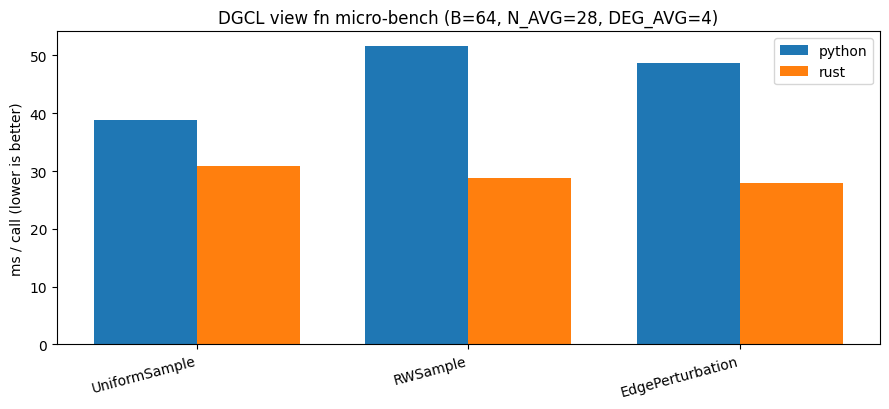

In [11]:
import matplotlib.pyplot as plt

if BENCH_VIEWS:
    print(f"{'view':<40s} {'python(ms)':>12s} {'rust(ms)':>12s} {'speedup':>10s}")
    print("-" * 78)
    for name, row in BENCH_VIEWS.items():
        py = row.get("python", float("nan"))
        rs = row.get("rust", float("nan"))
        sp = row.get("speedup", float("nan"))
        print(f"{name:<40s} {py:12.3f} {rs:12.3f} {sp:>9.2f}x")

    names = list(BENCH_VIEWS.keys())
    py_vals = [BENCH_VIEWS[n].get("python", 0.0) for n in names]
    rs_vals = [BENCH_VIEWS[n].get("rust", 0.0) for n in names]

    x = np.arange(len(names))
    w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.bar(x - w / 2, py_vals, width=w, label="python")
    ax.bar(x + w / 2, rs_vals, width=w, label="rust")
    ax.set_xticks(x)
    ax.set_xticklabels([n.split("(")[0] for n in names], rotation=15, ha="right")
    ax.set_ylabel("ms / call (lower is better)")
    ax.set_title(f"DGCL view fn micro-bench (B={B}, N_AVG={N_AVG}, DEG_AVG={DEG_AVG})")
    ax.legend()
    fig.tight_layout()
    out = FIGS_DIR / f"bars_views_{FIG_TS}.png"
    fig.savefig(out, dpi=150)
    print(f"saved: {out}")
    plt.show()
else:
    print("No view fn benchmark results collected.")

if BENCH_DATASET:
    print()
    print(f"{'loader':<30s} {'load(ms)':>10s} {'iter(ms)':>10s}")
    for k, v in BENCH_DATASET.items():
        print(f"{k:<30s} {v['load_ms']:10.2f} {v['iter_ms']:10.2f}")

    if "pt" in BENCH_DATASET and "shard" in BENCH_DATASET:
        labels = ["load", "iter"]
        pt_vals = [BENCH_DATASET["pt"]["load_ms"], BENCH_DATASET["pt"]["iter_ms"]]
        sh_vals = [BENCH_DATASET["shard"]["load_ms"], BENCH_DATASET["shard"]["iter_ms"]]
        x = np.arange(len(labels))
        fig, ax = plt.subplots(figsize=(6.5, 4.2))
        ax.bar(x - 0.2, pt_vals, width=0.4, label="MoleculeNet(pt)")
        ax.bar(x + 0.2, sh_vals, width=0.4, label="MoleculeNetShard(rust)")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel("ms (lower is better)")
        ax.set_title(f"Dataset load vs iterate — {MOLNET_NAME}")
        ax.legend()
        fig.tight_layout()
        out2 = FIGS_DIR / f"bars_dataset_{FIG_TS}.png"
        fig.savefig(out2, dpi=150)
        print(f"saved: {out2}")
        plt.show()